<Figure size 1200x800 with 0 Axes>

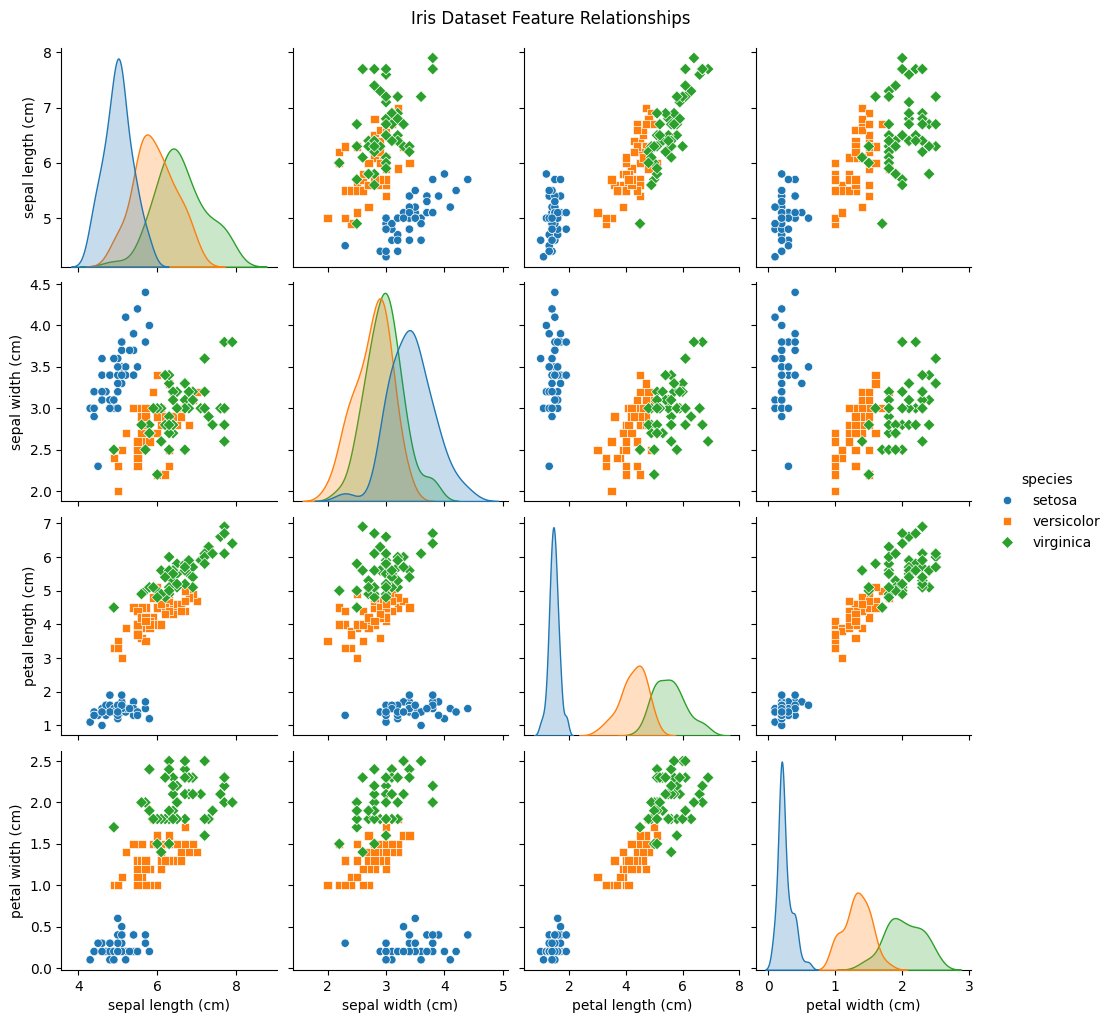

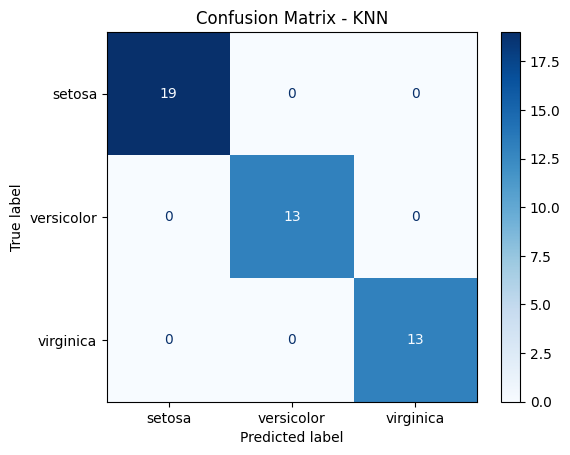

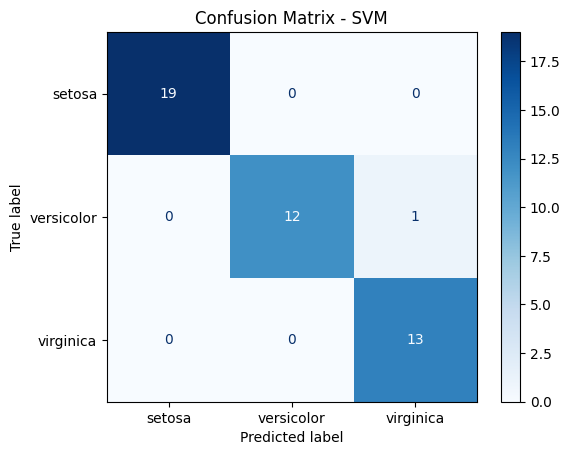

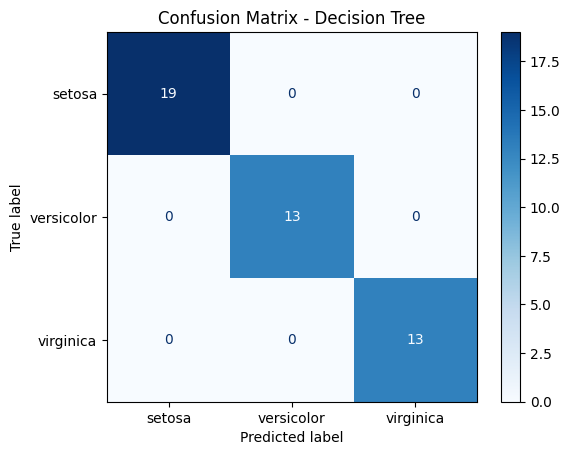


Model Comparison:

KNN:
Test Accuracy: 1.0000
Cross-validation: 0.9533 ± 0.0340

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


SVM:
Test Accuracy: 0.9778
Cross-validation: 0.9667 ± 0.0298

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Decision Tree:
Test Accuracy: 1.0000
Cross-val

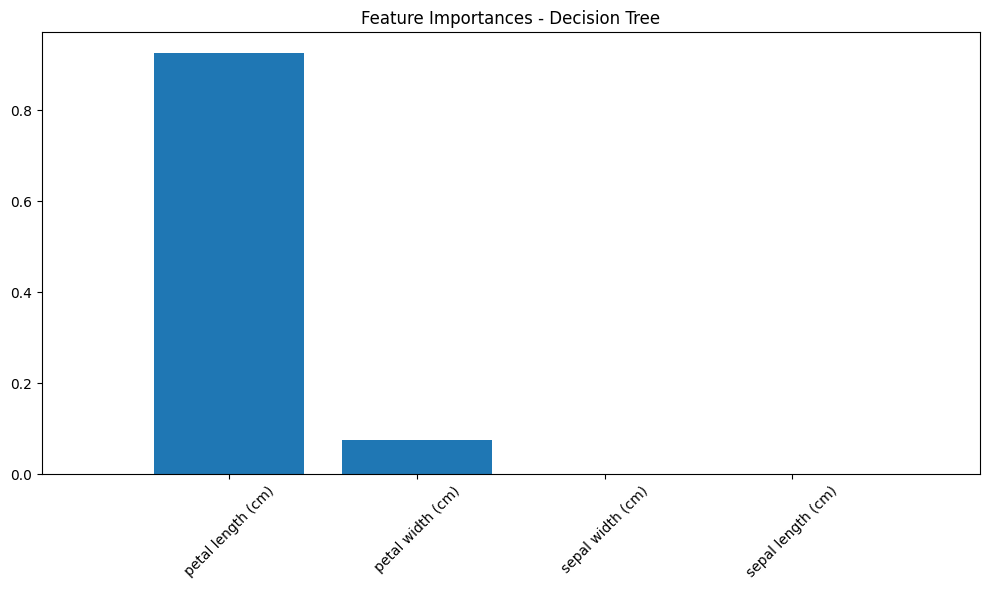

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                            classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame for visualization
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Data visualization
plt.figure(figsize=(12, 8))
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Iris Dataset Feature Relationships', y=1.02)
plt.show()

# Data preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'SVM': SVC(kernel='linear', C=1.0),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names)

    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=5)

    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'report': report,
        'cv_mean': np.mean(cv_scores),
        'cv_std': np.std(cv_scores)
    }

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Compare model performance
print("\nModel Comparison:")
print("="*50)
for name, result in results.items():
    print(f"\n{name}:")
    print(f"Test Accuracy: {result['accuracy']:.4f}")
    print(f"Cross-validation: {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
    print("\nClassification Report:")
    print(result['report'])

# Feature importance for Decision Tree
dt_model = results['Decision Tree']['model']
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Decision Tree")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()